Sprint 10, P2P: Jordi

In [1]:
import pandas as pd
import numpy as np 
from datetime import datetime

# nivel 3
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import Image, display




# Nivel 1
## 1. Importa como un DataFrame el archivo sprint10.xlsx. Asegúrate de que el fichero se importa correctamente, con los nombres de columnas que le corresponden, sin manipular el archivo original.
- fila 4 del excel entonces header = 3 
los nombres reales de columnas empiezan en la fila 4 visual del Excel

In [2]:
ruta = r"C:\Users\miren\OneDrive\Datos adjuntos\Documentos\Especialidad IT ACADEMY\sprint 10 Python Pandas\sprint10.xlsx"

sprint_10 = pd.read_excel(ruta,header = 3, index_col=0)


In [3]:
sprint_10

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
0,Inês,Ferreira Silva,16928694K,Portugal,Lisboa,25,2,1953,D,1.144 €,NaN,1.0,Grup B
1,Clara,Sánchez Martínez,27724652S,Espanya,Barcelona,18,3,1996,D,1.253 €,1.0,NaN,Grup A
2,Fatima,Fassi,38141675A,Marroc,Rabat,6,11,2005,A,1.441 €,1.0,NaN,Grup A
3,Khadija,Bennani Bennani,59157262R,Marroc,Rabat,20,1,1995,D,1.944 €,NaN,1.0,Grup B
4,Toni,Sánchez García,69630528M,Espanya,Barcelona,9,8,1999,H,1.043 €,NaN,1.0,Grup A
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Marta,Ferrer Ferrer,25161375F,Espanya,Sevilla,1,6,1951,D,1.216 €,NaN,1.0,Grup B
996,Joan,García,52145541P,Espanya,Sevilla,11,4,1959,H,971 €,NaN,1.0,Grup A
997,Laia,Ferrer Martínez,69760120X,Espanya,Barcelona,11,11,1980,D,682 €,NaN,1.0,Grup A
998,Jordi,García,82947791W,Espanya,Barcelona,23,5,1984,H,1.699 €,1.0,NaN,Grup C


Ordena el DataFrame por el país de origen. En caso de empate, ordena por el nombre de la ciudad.
Muestra las primeras 10 filas.

In [4]:
sprint_10 = sprint_10.sort_values(by=["País d'origen", "Ciutat"], ignore_index=True)
sprint_10.head(10)

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional
0,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A
1,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B
2,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.0,Grup B
3,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,D,1.557 €,1.0,NaN,Grup B
4,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,H,2.754 €,1.0,NaN,Grup D
5,Lea,Fischer,14773153R,Alemanya,Berlín,9,9,1986,D,1.370 €,1.0,NaN,Grup A
6,Lea,Müller,23266650S,Alemanya,Hamburg,14,4,2003,D,1.314 €,NaN,1.0,Grup A
7,Anna,Müller,83274277X,Alemanya,Hamburg,1,1,1987,D,2.464 €,NaN,1.0,Grup C
8,Laura,Schmidt Müller,60161784X,Alemanya,Hamburg,15,6,1987,NC,2.035 €,1.0,NaN,Grup C
9,Lukas,Müller Fischer,60982309S,Alemanya,Hamburg,28,3,1971,H,2.042 €,NaN,1.0,Grup B


Adicionalmente, haz un print donde compruebe que el DNI sólo tiene valores únicos.

In [5]:
print(sprint_10["DNI"].is_unique)

True


## 2. Crea una columna que sea el nombre completo.

In [6]:
sprint_10["Nom complet"] = sprint_10["Nom"] + " " + sprint_10["Cognoms"]

In [7]:
sprint_10.head()

,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nom complet
0,Mia,Schneider Fischer,28973553Z,Alemanya,Berlín,22,10,1976,A,951 €,NaN,1.0,Grup A,Mia Schneider Fischer
1,Laura,Schneider Fischer,37399141L,Alemanya,Berlín,2,2,1958,D,1.769 €,1.0,NaN,Grup B,Laura Schneider Fischer
2,Lea,Schneider Schneider,37368317L,Alemanya,Berlín,23,10,2005,D,2.013 €,NaN,1.0,Grup B,Lea Schneider Schneider
3,Mia,Fischer,21390098Z,Alemanya,Berlín,11,8,1950,D,1.557 €,1.0,NaN,Grup B,Mia Fischer
4,Jonas,Schneider,44060014R,Alemanya,Berlín,22,11,1985,H,2.754 €,1.0,NaN,Grup D,Jonas Schneider


Crea una columna si la persona es nacida en España o no.

In [8]:
sprint_10['Nascut aEspanya'] = np.where(sprint_10["País d'origen"] == 'Espanya', 'Sí', 'No')

In [9]:
filtro_pais = sprint_10["País d'origen"] == 'Espanya'   
sprint_10[filtro_pais].head()


,Nom,Cognoms,DNI,País d'origen,Ciutat,Dia de Naixement,Mes de Naixement,Any de Naixement,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nom complet,Nascut aEspanya
92,Clara,Sánchez Martínez,27724652S,Espanya,Barcelona,18,3,1996,D,1.253 €,1.0,NaN,Grup A,Clara Sánchez Martínez,Sí
93,Toni,Sánchez García,69630528M,Espanya,Barcelona,9,8,1999,H,1.043 €,NaN,1.0,Grup A,Toni Sánchez García,Sí
94,Toni,Martínez,14219925Z,Espanya,Barcelona,16,5,1964,H,891 €,NaN,1.0,Grup A,Toni Martínez,Sí
95,Oriol,Sánchez,40695825B,Espanya,Barcelona,27,7,1965,H,1.250 €,NaN,1.0,Grup A,Oriol Sánchez,Sí
96,Toni,Castells Romero,74222289K,Espanya,Barcelona,13,4,1961,H,1.438 €,NaN,1.0,Grup B,Toni Castells Romero,Sí


Pone el DNI como índice del DataFrame (nombres de filas).

In [10]:
sprint_10 = sprint_10.set_index("DNI")

Sustituye el nombre de las columnas Día de Nacimiento, Mes de Nacimiento y Año de Nacimiento por Día, Mes y Año.

In [11]:
sprint_10 = sprint_10.rename(columns={"Dia de Naixement": "Dia","Mes de Naixement": "Mes","Any de Naixement": "Año"})

Sustituye H por Hombre, D por Mujer, A por Otros y NC por un dato faltante (nan/null/na).


In [12]:
sprint_10["Gènere"] = sprint_10["Gènere"].replace({ "H": "Hombre", "D": "Mujer","A": "Otros","NC": np.nan})

Muestra todos los cambios que has realizado en una sola tabla.

In [13]:
sprint_10[['Dia', 'Mes', 'Año', 'Gènere', 'Nom complet', 'Nascut aEspanya']].head()


,Dia,Mes,Año,Gènere,Nom complet,Nascut aEspanya
DNI,,,,,,
28973553Z,22,10,1976,Otros,Mia Schneider Fischer,No
37399141L,2,2,1958,Mujer,Laura Schneider Fischer,No
37368317L,23,10,2005,Mujer,Lea Schneider Schneider,No
21390098Z,11,8,1950,Mujer,Mia Fischer,No
44060014R,22,11,1985,Hombre,Jonas Schneider,No


In [14]:
sprint_10.head()

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Año,Gènere,Salari mensual,Fills,No Fills,Grup Professional,Nom complet,Nascut aEspanya
DNI,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Otros,951 €,NaN,1.0,Grup A,Mia Schneider Fischer,No
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Mujer,1.769 €,1.0,NaN,Grup B,Laura Schneider Fischer,No
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Mujer,2.013 €,NaN,1.0,Grup B,Lea Schneider Schneider,No
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Mujer,1.557 €,1.0,NaN,Grup B,Mia Fischer,No
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Hombre,2.754 €,1.0,NaN,Grup D,Jonas Schneider,No


## 3. Junta las columnas Hijos y No Hijos en una sola columna, utilizando el método .apply() y definiendo una función que resuelva el problema. La columna nueva debe llamarse "Hijos" y tomar los valores "Sí" o "No".

In [15]:
def tiene_hijos(fila):
    """
    Determina si una persona tiene hijos a partir de las columnas 'Fills' y 'No Fills'.

    Args: fila (pd.Series): Fila del DataFrame.

    Returns: str | pd.NA: 'Sí' si tiene hijos, 'No' si no tiene hijos,
             o pd.NA si la información no está disponible.
    """
    if fila["Fills"] == 1:
        return "Sí"
    elif fila["No Fills"] == 1:
        return "No"
    else:
        return pd.NA


sprint_10["Hijos"] = sprint_10.apply(tiene_hijos, axis=1)

- Borramos las columnas "Fills" y "No Fills"

In [16]:
sprint_10.drop(columns=["Fills", "No Fills"], inplace=True)

In [17]:
sprint_10.head()

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Año,Gènere,Salari mensual,Grup Professional,Nom complet,Nascut aEspanya,Hijos
DNI,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Otros,951 €,Grup A,Mia Schneider Fischer,No,No
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Mujer,1.769 €,Grup B,Laura Schneider Fischer,No,Sí
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Mujer,2.013 €,Grup B,Lea Schneider Schneider,No,No
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Mujer,1.557 €,Grup B,Mia Fischer,No,Sí
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Hombre,2.754 €,Grup D,Jonas Schneider,No,Sí


## 4. Crea una tabla resumen que permita ver el sueldo medio, mediano, mínimo y máximo por Género.
-  primero tenemos que transformar (1.144€) de str a float, strip() pos si hay espacios en blanco

In [18]:
sprint_10["Salari mensual"] = (
    sprint_10["Salari mensual"]
    .str.strip()
    .str.replace("€", "", regex=False)
    .str.replace(".", "", regex=False)
    .astype(float)
)

In [19]:
tabla_resumen = sprint_10.groupby("Gènere")["Salari mensual"].agg(
    Media="mean",
    Mediana="median",
    Minimo="min",
    Maximo="max"
).round(2)

tabla_resumen

,Media,Mediana,Minimo,Maximo
Gènere,,,,
Hombre,1643.25,1531.0,737.0,3356.0
Mujer,1469.44,1361.5,665.0,3021.0
Otros,1626.59,1545.0,703.0,3175.0


Ordena la tabla en función del sueldo medio.

In [20]:
tabla_resumen = tabla_resumen.sort_values(by="Media")
tabla_resumen

,Media,Mediana,Minimo,Maximo
Gènere,,,,
Mujer,1469.44,1361.5,665.0,3021.0
Otros,1626.59,1545.0,703.0,3175.0
Hombre,1643.25,1531.0,737.0,3356.0


## 5.Crea una tabla resumen con el salario medio por género (filas) y país de origen (columnas).

Añade las medias en los márgenes de la mesa   -->   (margins=True,margins_name="Total")

(EXTRA): Aplica formato condicional en la tabla para ver en un color más intenso los valores más elevados

-- > style.background_gradient( cmap="YlOrRd",axis=None)
-- > importante: .round(2)            redondea los valores del DataFrame
-- >             .format("{:.2f}")    como se ven los valores dentro de la tabla

In [21]:
sueldo_pais = sprint_10.pivot_table(index="Gènere",columns="País d'origen",values="Salari mensual",aggfunc="mean",
    margins=True, margins_name="Total").round(2)
sueldo_pais.head()


País d'origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,Total
Gènere,,,,,,,,,,,
Hombre,2067.43,1583.29,1554.67,1682.11,1389.25,1672.88,1531.00,1625.00,1497.00,1162.56,1643.25
Mujer,1804.31,1291.80,1497.75,1460.16,1566.47,1247.18,1405.21,1517.80,1488.55,1489.46,1469.44
Otros,951.00,1141.00,1030.00,1706.18,NaN,1423.00,1365.00,1372.00,1765.00,1921.00,1626.59
Total,1851.38,1463.39,1495.54,1581.21,1462.73,1425.95,1447.33,1558.42,1523.33,1423.56,1560.99


In [22]:
sueldo_pais.style.background_gradient( cmap="YlOrRd",axis=None).format("{:.2f}")

País d'origen,Alemanya,Argentina,Colòmbia,Espanya,França,Itàlia,Marroc,Mèxic,Portugal,Regne Unit,Total
Gènere,,,,,,,,,,,
Hombre,2067.43,1583.29,1554.67,1682.11,1389.25,1672.88,1531.00,1625.00,1497.00,1162.56,1643.25
Mujer,1804.31,1291.80,1497.75,1460.16,1566.47,1247.18,1405.21,1517.80,1488.55,1489.46,1469.44
Otros,951.00,1141.00,1030.00,1706.18,nan,1423.00,1365.00,1372.00,1765.00,1921.00,1626.59
Total,1851.38,1463.39,1495.54,1581.21,1462.73,1425.95,1447.33,1558.42,1523.33,1423.56,1560.99


## 6. Crea una columna nueva que sea la fecha de nacimiento en formato Datetime a partir de las columnas día, mes y año.


In [23]:
sprint_10["Fecha_nacimiento"] = pd.to_datetime({"year": sprint_10["Año"],"month": sprint_10["Mes"], "day": sprint_10["Dia"]})



Utilizando esta columna crea una función que dada una fecha, te calcule la edad actual a día de hoy.

In [24]:
def calcular_edad(fecha):
    """
    Calcula la edad de una persona.
    
    A partir de su fecha de nacimiento.
    
    """
    hoy = datetime.today()
    edad = hoy.year - fecha.year

    if (hoy.month, hoy.day) < (fecha.month, fecha.day):
        edad -= 1
    return edad

sprint_10["Edad"] = sprint_10["Fecha_nacimiento"].apply(calcular_edad)
print(sprint_10[["Fecha_nacimiento", "Edad"]].head())

          Fecha_nacimiento  Edad
DNI                             
28973553Z       1976-10-22    49
37399141L       1958-02-02    68
37368317L       2005-10-23    20
21390098Z       1950-08-11    75
44060014R       1985-11-22    40


In [25]:
sprint_10.head()

,Nom,Cognoms,País d'origen,Ciutat,Dia,Mes,Año,Gènere,Salari mensual,Grup Professional,Nom complet,Nascut aEspanya,Hijos,Fecha_nacimiento,Edad
DNI,,,,,,,,,,,,,,,
28973553Z,Mia,Schneider Fischer,Alemanya,Berlín,22,10,1976,Otros,951.0,Grup A,Mia Schneider Fischer,No,No,1976-10-22,49
37399141L,Laura,Schneider Fischer,Alemanya,Berlín,2,2,1958,Mujer,1769.0,Grup B,Laura Schneider Fischer,No,Sí,1958-02-02,68
37368317L,Lea,Schneider Schneider,Alemanya,Berlín,23,10,2005,Mujer,2013.0,Grup B,Lea Schneider Schneider,No,No,2005-10-23,20
21390098Z,Mia,Fischer,Alemanya,Berlín,11,8,1950,Mujer,1557.0,Grup B,Mia Fischer,No,Sí,1950-08-11,75
44060014R,Jonas,Schneider,Alemanya,Berlín,22,11,1985,Hombre,2754.0,Grup D,Jonas Schneider,No,Sí,1985-11-22,40


# Nivel 2
## 1. Utilizando el siguiente DataFrame, adjunta la columna "Incremento" al dataframe del nivel anterior.

In [26]:
df_incremento = pd.DataFrame({
    "Grupo": ["Grupo A", "Grupo B", "Grupo C", "Grupo D"],
    "Incremento": ["5%", "3,5%", "2%", "8%"]
})


In [27]:
df_incremento

,Grupo,Incremento
0,Grupo A,5%
1,Grupo B,"3,5%"
2,Grupo C,2%
3,Grupo D,8%


Actualiza la columna salario en función de los porcentajes que se adjuntan. No modifiques manualmente los incrementos, escribe código Python para hacer las conversiones necesarias.

In [28]:
sprint_10["Grupo"] = sprint_10["Grup Professional"].str.replace("Grup", "Grupo", regex=False) 

sprint_10 = sprint_10.merge(df_incremento, on="Grupo", how="left") 

sprint_10["Incremento"] = (                              
    sprint_10["Incremento"]
    .str.replace("%", "", regex=False)
    .str.replace(",", ".", regex=False)
    .astype(float) / 100
)

sprint_10["Salari actualizado"] = (sprint_10["Salari mensual"] * (1 + sprint_10["Incremento"])).round(2)  

In [29]:
sprint_10[["Grupo", "Salari mensual", "Incremento", "Salari actualizado"]].head()

,Grupo,Salari mensual,Incremento,Salari actualizado
0,Grupo A,951.0,0.050,998.55
1,Grupo B,1769.0,0.035,1830.92
2,Grupo B,2013.0,0.035,2083.46
3,Grupo B,1557.0,0.035,1611.50
4,Grupo D,2754.0,0.080,2974.32


## 2. Utilizando un bucle, exporta en 4 ficheros (formato .xlsx o .csv) los datos de cada Grupo Profesional.
Por ejemplo: "dades_GrupA.xlsx" , "dades_GrupB.xlsx" ...

In [30]:
for grupo in sprint_10["Grup Professional"].unique():

  
    df_grupo = sprint_10[sprint_10["Grup Professional"] == grupo]

   
    nombre_fichero = f"dades_{grupo.replace(' ', '')}.xlsx"

   
    df_grupo.to_excel(nombre_fichero, index=False)

    print(f"Fichero creado: {nombre_fichero}")


Fichero creado: dades_GrupA.xlsx
Fichero creado: dades_GrupB.xlsx
Fichero creado: dades_GrupD.xlsx
Fichero creado: dades_GrupC.xlsx


Exporta un 5º DataFrame en formato .xlsx o .csv que contenga cuántos trabajadores hay por cada Grupo Profesional, cuál es su sueldo medio y cuál es su edad media.

In [31]:
df_resumen = (
    sprint_10.groupby("Grup Professional")
      .agg(
          Trabajadores=("Grup Professional", "count"),
          Salario_medio=("Salari mensual", "mean"),
          Edad_media=("Edad", "mean")
      )
      .round(2)
      .reset_index()
)
df_resumen

,Grup Professional,Trabajadores,Salario_medio,Edad_media
0,Grup A,490,1155.55,49.46
1,Grup B,318,1666.23,48.21
2,Grup C,137,2244.31,51.25
3,Grup D,55,2871.13,45.31


In [32]:
df_resumen.to_excel("resumen_trabajadores.xlsx", index=False)


# Nivel 3
El nivel 3 de este sprint es totalmente diferente a otros sprints que has hecho hasta ahora, ya que son ejercicios más abstractos que requieren pelearse bastante. No continúan con el mismo dataset de los niveles anteriores, sino que te plantean dos situaciones nuevas totalmente diferentes entre ellas.

## 1. Crea una función que tome un dataframe como parámetro de entrada.

La función debe crear (y exportar) un gráfico automáticamente para cada columna del dataframe. Por ejemplo:

un histograma/boxplot si la variable es numérica
unas barras de los valores más frecuentes si es categórica
unas barras de los años más frecuentes si el dato está en formato data.
La idea es crear una función que funcione por cualquier dataframe, no sólo con lo que hemos trabajado hasta ahora.



In [33]:
def limpiar_nombre_archivo(nombre_columna):
    """
    Limpia el nombre de una columna para poder usarlo como nombre de archivo.

    Parámetros: nombre_columna (str): Nombre original de la columna.

    Retorna: str: Nombre limpio para guardar el gráfico.
    """
    return (
        str(nombre_columna)
        .strip()
        .replace(" ", "_")
        .replace("/", "_")
        .replace("\\", "_")
        .replace("'", "")
        .replace('"', "")
    )


def exportar_graficos_dataframe(df, carpeta_salida="graficos", top_categorias=10):
    """
    Genera gráficos automáticamente según el tipo de variable
    y los guarda en una carpeta.
    """
    ruta_salida = Path(carpeta_salida)
    ruta_salida.mkdir(parents=True, exist_ok=True)

    for columna in df.columns:
        serie = df[columna].dropna()

        if serie.empty:
            continue

        nombre_archivo = limpiar_nombre_archivo(columna)

        fig, ax = plt.subplots(figsize=(8, 5))

        if pd.api.types.is_bool_dtype(serie):
            serie.value_counts().plot.bar(ax=ax)
            ax.set_title(f"Frecuencia de {columna}")
            ax.set_xlabel(columna)
            ax.set_ylabel("Frecuencia")

        elif pd.api.types.is_numeric_dtype(serie):
            serie.plot.hist(ax=ax, bins=20)
            ax.set_title(f"Histograma de {columna}")
            ax.set_xlabel(columna)
            ax.set_ylabel("Frecuencia")

        elif pd.api.types.is_datetime64_any_dtype(serie):
            serie.dt.year.value_counts().sort_index().plot.bar(ax=ax)
            ax.set_title(f"Años más frecuentes de {columna}")
            ax.set_xlabel("Año")
            ax.set_ylabel("Frecuencia")

        else:
            serie.astype(str).value_counts().head(top_categorias).plot.bar(ax=ax)
            ax.set_title(f"Valores más frecuentes de {columna}")
            ax.set_xlabel(columna)
            ax.set_ylabel("Frecuencia")

        fig.tight_layout()
        fig.savefig(ruta_salida / f"{nombre_archivo}.png")
        plt.close(fig)

llamada a la función

In [34]:
exportar_graficos_dataframe(sprint_10)

lo comprobamos

In [35]:
os.listdir("graficos")

['Año.png',
 'Ciutat.png',
 'Cognoms.png',
 'Dia.png',
 'Edad.png',
 'Fecha_nacimiento.png',
 'Grupo.png',
 'Grup_Professional.png',
 'Gènere.png',
 'Hijos.png',
 'Incremento.png',
 'Mes.png',
 'Nascut_aEspanya.png',
 'Nom.png',
 'Nom_complet.png',
 'País_dorigen.png',
 'Salari_actualizado.png',
 'Salari_mensual.png']

Muestra el resultado de la función en alguno de los datasets de ejemplo que contiene el paquete seaborn. Por ejemplo, iris, peguens o titanic.

Ten en consideración que en el siguiente sprint trabajarás exclusivamente con gráficos. El objetivo de este ejercicio no es crear gráficos muy elaborados, sino resolver una necesidad de manera rápida y automática.

In [36]:
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


ejecutamos la función y mostramos

In [37]:
exportar_graficos_dataframe(titanic, carpeta_salida="graficos_titanic")

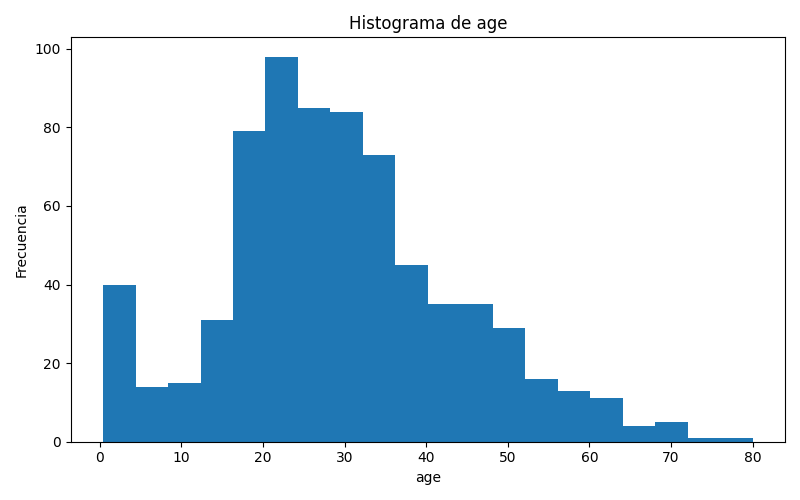

In [38]:
display(Image("graficos_titanic/age.png"))

## 2. Carga el archivo matriu_distancies.xlsx pandas, de manera que los nombres de filas y los nombres de columnas sean los de las ciudades. Borra "Las Palmas de Gran Canaria" y "Palma" para que podamos hacer el trayecto en coche.

In [40]:
ruta = r"C:\Users\miren\OneDrive\Datos adjuntos\Documentos\Especialidad IT ACADEMY\sprint 10 Python Pandas\matriu_distancies.xlsx"
df_distancias = pd.read_excel(ruta ,index_col=0)

df_distancias



,Barcelona,Valencia,Sevilla,Zaragoza,Málaga,Murcia,Palma,Las Palmas de Gran Canaria,Bilbao,Alicante,Córdoba,Valladolid,Vigo,Gijón,Hospitalet de Llobregat
Barcelona,NaN,303.0,831.0,256.0,770.0,471.0,206.0,2175.0,469.0,407.0,711.0,576.0,908.0,686.0,7.0
Valencia,303.0,NaN,541.0,246.0,468.0,177.0,260.0,1874.0,473.0,125.0,421.0,441.0,766.0,632.0,297.0
Sevilla,831.0,541.0,NaN,646.0,158.0,433.0,791.0,1355.0,703.0,495.0,121.0,486.0,588.0,685.0,824.0
Zaragoza,256.0,246.0,646.0,NaN,628.0,408.0,377.0,2001.0,246.0,368.0,535.0,320.0,652.0,444.0,250.0
Málaga,770.0,468.0,158.0,628.0,NaN,323.0,695.0,1406.0,739.0,391.0,133.0,549.0,716.0,766.0,763.0
Murcia,471.0,177.0,433.0,408.0,323.0,NaN,372.0,1723.0,606.0,69.0,320.0,510.0,800.0,726.0,465.0
Palma,206.0,260.0,791.0,377.0,695.0,372.0,NaN,2093.0,621.0,303.0,671.0,664.0,1000.0,820.0,204.0
Las Palmas de Gran Canaria,2175.0,1874.0,1355.0,2001.0,1406.0,1723.0,2093.0,NaN,2022.0,1792.0,1470.0,1790.0,1682.0,1925.0,2168.0
Bilbao,469.0,473.0,703.0,246.0,739.0,606.0,621.0,2022.0,NaN,583.0,618.0,232.0,486.0,223.0,465.0
Alicante,407.0,125.0,495.0,368.0,391.0,69.0,303.0,1792.0,583.0,NaN,379.0,515.0,821.0,722.0,401.0


In [41]:
df_distancias = df_distancias.drop(
    index=["Palma", "Las Palmas de Gran Canaria"],
    columns=["Palma", "Las Palmas de Gran Canaria"]
)

In [42]:
df_distancias.head()

,Barcelona,Valencia,Sevilla,Zaragoza,Málaga,Murcia,Bilbao,Alicante,Córdoba,Valladolid,Vigo,Gijón,Hospitalet de Llobregat
Barcelona,NaN,303.0,831.0,256.0,770.0,471.0,469.0,407.0,711.0,576.0,908.0,686.0,7.0
Valencia,303.0,NaN,541.0,246.0,468.0,177.0,473.0,125.0,421.0,441.0,766.0,632.0,297.0
Sevilla,831.0,541.0,NaN,646.0,158.0,433.0,703.0,495.0,121.0,486.0,588.0,685.0,824.0
Zaragoza,256.0,246.0,646.0,NaN,628.0,408.0,246.0,368.0,535.0,320.0,652.0,444.0,250.0
Málaga,770.0,468.0,158.0,628.0,NaN,323.0,739.0,391.0,133.0,549.0,716.0,766.0,763.0


Nos interesa visitar todas las ciudades principales de España recorriendo la mínima distancia posible.

No es necesario que lo hagas de forma óptima, nos interesa que desarrolles una solución razonable utilizando las herramientas que tienes actualmente.

No es necesario que lo hagas de forma óptima, nos interesa que desarrolles una solución razonable utilizando las herramientas que tienes actualmente.

Por ejemplo, una aproximación sencilla (que no óptima) sería yendo siempre a la ciudad más cercana que no hayamos visitado todavía.

Haz una función que dada la matriz de distancias y la ciudad de origen, haga una propuesta de ruta que sea lo más corta posible que puedas, devolviendo una lista con la orden de visita. Da también la distancia total recorrida.



In [43]:
def calcular_ruta_cercana(matriz_distancias, ciudad_origen):
    """
    Calcula una ruta aproximada visitando siempre la ciudad más cercana.
    Devuelve la ruta completa y la distancia total recorrida.
    """
    ciudades_pendientes = set(matriz_distancias.index)
    ruta = [ciudad_origen]
    ciudad_actual = ciudad_origen
    distancia_total = 0

    ciudades_pendientes.remove(ciudad_origen)

    while ciudades_pendientes:
        distancias = matriz_distancias.loc[ciudad_actual, list(ciudades_pendientes)]
        siguiente_ciudad = distancias.idxmin()
        distancia_total += distancias[siguiente_ciudad]

        ruta.append(siguiente_ciudad)
        ciudades_pendientes.remove(siguiente_ciudad)
        ciudad_actual = siguiente_ciudad

    return ruta, distancia_total

In [44]:
ruta, distancia_total = calcular_ruta_cercana(df_distancias, "Bilbao")

print(ruta)
print(f"Distancia total: {distancia_total:.2f} km")

['Bilbao', 'Gijón', 'Valladolid', 'Zaragoza', 'Valencia', 'Alicante', 'Murcia', 'Córdoba', 'Sevilla', 'Málaga', 'Vigo', 'Hospitalet de Llobregat', 'Barcelona']
Distancia total: 3431.00 km


(EXTRA) Desde qué ciudad la ruta sería más corta con el algoritmo planteado

In [45]:
def buscar_mejor_origen(matriz_distancias):
    """
    Calcula la ruta desde cada ciudad posible.
    
    Devuelve la ciudad con menor distancia total.
    """
    resultados = []

    for ciudad in matriz_distancias.index:
        ruta, distancia_total = calcular_ruta_cercana(
            matriz_distancias,
            ciudad
        )

        resultados.append({
            "ciudad_origen": ciudad,
            "ruta": ruta,
            "distancia_total": distancia_total
        })

    df_resultados = pd.DataFrame(resultados)
    mejor_ruta = df_resultados.loc[df_resultados["distancia_total"].idxmin()]

    return mejor_ruta, df_resultados

In [46]:
mejor_ruta, df_resultados = buscar_mejor_origen(df_distancias)

print(f"Mejor ciudad de origen: {mejor_ruta['ciudad_origen']}")
print(f"Distancia total: {mejor_ruta['distancia_total']:.2f} km")
print(mejor_ruta["ruta"])

Mejor ciudad de origen: Barcelona
Distancia total: 2646.00 km
['Barcelona', 'Hospitalet de Llobregat', 'Zaragoza', 'Bilbao', 'Gijón', 'Valladolid', 'Vigo', 'Sevilla', 'Córdoba', 'Málaga', 'Murcia', 'Alicante', 'Valencia']


In [47]:
df_resultados.sort_values( "distancia_total").head(1).reset_index(drop=True)

,ciudad_origen,ruta,distancia_total
0,Barcelona,"[Barcelona, Hospitalet de Llobregat, Zaragoza,...",2646.0


fin sprint 10